# Exploring conceptual model for Wahpeton Model 

This note book aims to test if we can get water in from the Otter tail river area into the Buried Valley aquifer so that the Buried Valley aquifer heads match the river stage in the Otter Tail area. 
To do this we force:
 1. vertical Ks to a high value in layers 1-3 in the area around Otter Tail
 2. confine vks in all other areas so that Buried Vallley stays confined every where else
 3. we remove the recharge package and ghbs because we are fully focused on the river/confied aquifer dynamics 

In [1]:
import os 
import sys
import shutil 
from datetime import datetime
sys.path.insert(0,os.path.abspath(os.path.join('..','..','..','dependencies')))
sys.path.insert(1,os.path.abspath(os.path.join('..','..','..','dependencies','flopy')))
sys.path.insert(2,os.path.abspath(os.path.join('..','..','..','dependencies','pyemu')))
import pyemu
import flopy
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import geopandas as gpd
from typing import Sequence, Union


C:\Users\mbeck\AppData\Local\miniforge3\envs\nddwrpy311\Lib\site-packages\geopandas\_compat.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).


load clean modflow files adn run to make sure you are starting from a good place:

In [2]:
run_tag = '03'
test_case = f'test_case_{run_tag}'

# orginal workspace:
ows = os.path.join('..','model_ws','wahp_clean')
# test case directory:
w_d = test_case

if os.path.exists(w_d):
    shutil.rmtree(w_d)
shutil.copytree(ows, w_d)

pyemu.utils.run("mf6",cwd=w_d)

mf6.exe


load sim and all gwf packages we want to modify:

In [3]:
sim = flopy.mf6.MFSimulation.load(sim_ws=w_d,version="mf6")
gwf = sim.get_model()

nrows = gwf.modelgrid.nrow
ncols = gwf.modelgrid.ncol
delr = gwf.modelgrid.delr[0]
id = gwf.dis.idomain.array
npf = gwf.npf


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package drn...
    loading package rch...
    loading package ghb...
    loading package oc...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package obs...
  loading solution package wahp...


load npf package and print out the inital Khs and Kv by layer.
*** Note model is homogenous in each layer ***

In [4]:
# npf
kh_files = [f for f in os.listdir(w_d) if f.startswith('npf_k_')]
kh_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
init_kh = {}
for file in kh_files:
    kh = np.loadtxt(os.path.join(w_d, file))
    med_kh = np.median(kh)
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    print(f"Layer {ly} initial kh: {med_kh}")    
    init_kh[ly] = med_kh

print('-'*35)

aniso_files = [f for f in os.listdir(w_d) if f.startswith('npf_k33')]
# sort files by layer number:
aniso_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
init_aniso = {}
for file in aniso_files:
    # read in with numpy
    aniso = np.loadtxt(os.path.join(w_d, file))
    med_ansio = np.median(aniso)    
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    print(f"Layer {ly} initial anisotropy: {med_ansio}")
    init_aniso[ly] = med_ansio

print('-'*35)
    
# print out actual kv vals:
for key in init_kh.keys():
    kv = init_aniso[key]*init_kh[key]
    print(f"Layer {key} initial kv: {kv}")

print('-'*35)

icell_files = [f for f in os.listdir(w_d) if f.startswith('npf_icell')]
icell_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
for file in icell_files:
    icell = np.loadtxt(os.path.join(w_d, file))
    unq = np.unique(icell)
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    print(f"Layer {ly} unique icell vals: {unq}")  
    # if ones in icell, then there are convertiable cells, else all confined
    if np.all(icell == 1):
        print(f"    -layer {ly} has convertiable cells")
    else:
        print(f"    - layer {ly} is all confined")
      
print('-'*35)

Layer 1 initial kh: 50.0
Layer 2 initial kh: 245.0
Layer 3 initial kh: 245.0
Layer 4 initial kh: 245.0
Layer 5 initial kh: 5.0
Layer 6 initial kh: 245.0
-----------------------------------
Layer 1 initial anisotropy: 0.1
Layer 2 initial anisotropy: 0.1
Layer 3 initial anisotropy: 0.1
Layer 4 initial anisotropy: 0.1
Layer 5 initial anisotropy: 0.1
Layer 6 initial anisotropy: 0.1
-----------------------------------
Layer 1 initial kv: 5.0
Layer 2 initial kv: 24.5
Layer 3 initial kv: 24.5
Layer 4 initial kv: 24.5
Layer 5 initial kv: 0.5
Layer 6 initial kv: 24.5
-----------------------------------
Layer 1 unique icell vals: [1.]
    -layer 1 has convertiable cells
Layer 2 unique icell vals: [0.]
    - layer 2 is all confined
Layer 3 unique icell vals: [0.]
    - layer 3 is all confined
Layer 4 unique icell vals: [0.]
    - layer 4 is all confined
Layer 5 unique icell vals: [0.]
    - layer 5 is all confined
Layer 6 unique icell vals: [0.]
    - layer 6 is all confined
---------------------

remove all packages but riv and set tdis to 1 sp

In [19]:

nam_file = "wahp.nam"
pkgs_to_remove = ("RCH", "WEL", "GHB", "DRN")   # package names (first word)

nam_path = os.path.join(w_d, nam_file)
with open(nam_path, "r") as f:
    lines = f.readlines()

filtered_lines = [
    line for line in lines
    if not line.lstrip().startswith(pkgs_to_remove)
]

with open(nam_path, "w") as f:
    f.writelines(filtered_lines)

print(f"Removed {pkgs_to_remove} from {nam_file}")

# -------------------------------------------------------------------------
# 2)  .NPF  ─ tell MODFLOW to save specific discharge
# -------------------------------------------------------------------------
npf_file = "wahp.npf"
npf_path = os.path.join(w_d, npf_file)

with open(npf_path, "r") as f:
    lines = f.readlines()

already_there = any("SAVE_SPECIFIC_DISCHARGE" in l.upper() for l in lines)
if not already_there:
    for i, line in enumerate(lines):
        if line.strip().upper() == "END OPTIONS":
            lines.insert(i, "  SAVE_SPECIFIC_DISCHARGE\n")
            break

    with open(npf_path, "w") as f:
        f.writelines(lines)

    print(f"Inserted SAVE_SPECIFIC_DISCHARGE into {npf_file}")
else:
    print("SAVE_SPECIFIC_DISCHARGE already present in .npf file")

# -------------------------------------------------------------------------
# 3)  TDIS  ─ use Flopy to set a single steady-state stress period
# -------------------------------------------------------------------------
#   • nper         = 1
#   • period data  = (1 day, 1 time-step, tsmult 1.0)
#   • everything else (OPTIONS, TIME_UNITS, etc.) stays as it was

sim = flopy.mf6.MFSimulation.load(sim_ws=w_d, exe_name="mf6")

sim.tdis.nper.set_data(1)
sim.tdis.perioddata.set_data([(1.0, 1, 1.0)])   # length, nstp, tsmult

sim.write_simulation()
print("TDIS updated → single steady-state period written to disk")




Removed ('RCH', 'WEL', 'GHB', 'DRN') from wahp.nam
SAVE_SPECIFIC_DISCHARGE already present in .npf file
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package oc...
    loading package obs...
  loading solution package wahp...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package wahp...
  writing model wahp...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package riv...
    writing package oc...
    writing package head_obs...
TDIS updated → single steady-state period written to disk


now mask area for high vk

C:\Users\mbeck\AppData\Local\Temp\ipykernel_48048\2977097140.py:32: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


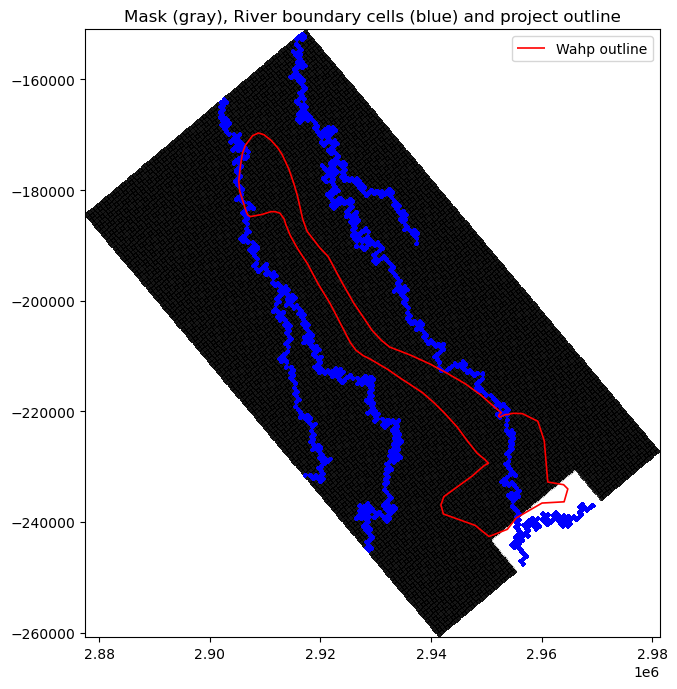

In [14]:
rows = np.arange(141, 152)
cols = np.arange(29, 59)
mask = np.zeros((nrows, ncols), dtype=int)
mask[np.ix_(rows - 1, cols - 1)] = 1

# ----------------- outline shapefile (same CRS caveat) ---------------
outline_fp = os.path.join(
    "..", "..", "..", "gis", "input_shps", "wahp", "wahp_outline_full.shp"
)
wahp_outline = gpd.read_file(outline_fp)
if wahp_outline.crs is None:
    wahp_outline.set_crs(gwf.modelgrid.crs, inplace=True)

# ----------------- map view -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
mv = flopy.plot.PlotMapView(model=gwf, ax=ax)

# base array
mv.plot_array(mask, cmap="gray", alpha=0.7)

# **Flopy way** to draw the river‐package cells
mv.plot_bc(package=gwf.riv, color="blue", lw=0.8, label="River package")

# (optional) drains in green, wells in red, etc.
# mv.plot_bc(package=gwf.drn, color="green", lw=0.8, label="Drain package")
# mv.plot_bc(package=gwf.wel, color="red",  marker="o", ms=3, label="Wells")

# outline
wahp_outline.boundary.plot(ax=ax, color="red", linewidth=1.2, label="Wahp outline")

ax.set_title("Mask (gray), River boundary cells (blue) and project outline")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Layer 3 new anisotropy field  →  min=1.00e-10, max=1.00e-01


C:\Users\mbeck\AppData\Local\Temp\ipykernel_48048\1654441503.py:69: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


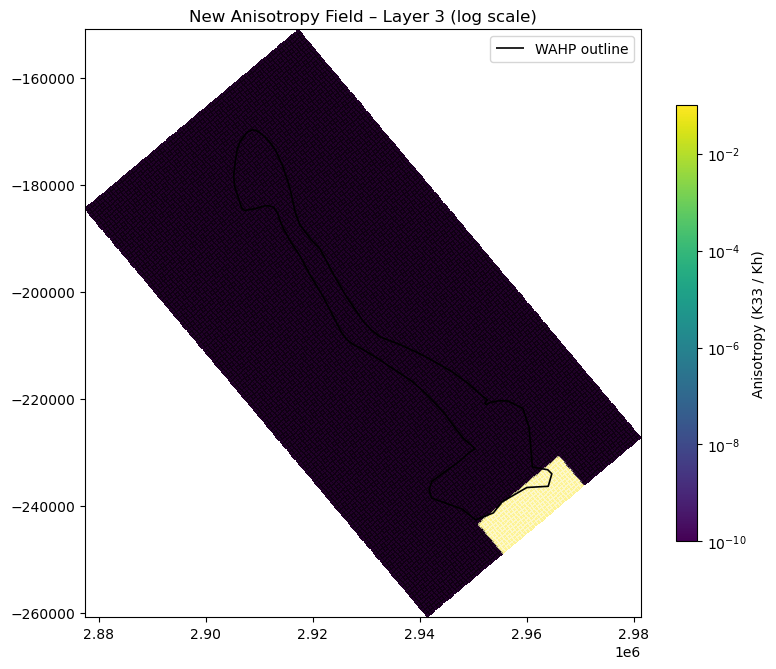

In [17]:
from matplotlib.colors import LogNorm
rows = np.arange(141, 152)          # 1-based index in your earlier example
cols = np.arange(29, 59)

mask = np.zeros((nrows, ncols), dtype=int)
mask[np.ix_(rows - 1, cols - 1)] = 1      # convert to 0-based Python index

# ------------------------------------------------------------
# 2) Load anisotropy files, modify layer-3 array, plot & save
# ------------------------------------------------------------
aniso_files = sorted(
    [f for f in os.listdir(w_d) if f.startswith("npf_k33_")],
    key=lambda x: int(x.split("_")[2].split(".")[0].replace("layer", ""))
)

for file in aniso_files:
    ly = int(file.split("_")[2].split(".")[0].replace("layer", ""))  # zero-based layer #

    if ly != 3:
        continue  # only handle layer 3 in this loop

    # ---- read original anisotropy array ---------------------------------
    aniso = np.loadtxt(os.path.join(w_d, file))          # 2-D (nrow × ncol)

    # ---- apply mask: keep original where mask == 1, insert tiny value elsewhere
    aniso_mod = aniso.copy()
    aniso_mod[mask == 0] = 1e-10     # or whatever “very low” value you want

    print(f"Layer {ly} new anisotropy field  →  min={aniso_mod.min():.2e}, "
          f"max={aniso_mod.max():.2e}")

    # ---- Flopy map view plot --------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 7))
    mv = flopy.plot.PlotMapView(model=gwf, layer=ly, ax=ax)

    # (a) modified anisotropy
    mv.plot_array(
        aniso_mod,
        cmap="viridis",
        norm=LogNorm(vmin=aniso_mod.min(), vmax=aniso_mod.max()),
        alpha=0.9,
    )

    # (b) mask overlay
    mv.plot_array(mask, cmap="gray", alpha=0.3)

    # (c) river-package cells
    mv.plot_bc(package=gwf.riv, color="blue", lw=0.8, label="River package")

    # (d) outline shapefile
    outline_fp = os.path.join(
        "..", "..", "..", "gis", "input_shps", "wahp", "wahp_outline_full.shp"
    )
    wahp_outline = gpd.read_file(outline_fp)


    wahp_outline.boundary.plot(ax=ax, color="black", linewidth=1.2, label="WAHP outline")

    # ----- final touches --------------------------------------------------
    ax.set_title("New Anisotropy Field – Layer 3 (log scale)")
    cbar = plt.colorbar(
        plt.cm.ScalarMappable(
            norm=LogNorm(vmin=aniso_mod.min(), vmax=aniso_mod.max()), cmap="viridis"
        ),
        ax=ax,
        shrink=0.7,
        label="Anisotropy (K33 / Kh)",
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # ---- overwrite the original text file with modified values ----------
    np.savetxt(os.path.join(w_d, file), aniso_mod, fmt="%.12f")


now modify .nam to remove recharge and ghb package and also modify npf to add save_specific discharge flag for vector plot:


now rerun model and your fingers it runs:

In [20]:
pyemu.utils.run("mf6",cwd=w_d)

mf6.exe


In [22]:
def plot_hds(
    model_ws: Union[str, os.PathLike],
    sim_name: str = "wahp",
    kstpkper: tuple[int, int] = (0, 0),
    layers: Union[str, Sequence[int]] = "all",
    show_bc: bool = True,
    bc_colors: dict[str, str] | None = None,
    out_dir: str = "fig_heads",
    dpi: int = 300,
):
    """
    Colour-flood head maps with boundary conditions, compatible with
    older FloPy versions (uses PlotMapView.plot_bc).

    Parameters
    ----------
    model_ws
        Workspace containing the simulation.
    sim_name
        GWF model name (same as *.nam* prefix).
    kstpkper
        (kstp, kper) tuple to extract from *.hds*.
    layers
        'all' or iterable of 0-based layer indices.
    show_bc
        Toggle RIV, GHB, CHD overlays (DRN removed).
    bc_colors
        Dict of colours for each BC.
    out_dir
        Sub-folder for PNGs.
    dpi
        Output resolution.
    """
    bc_colors = bc_colors or dict(
        riv="dodgerblue",
        ghb="limegreen",
        chd="magenta",
    )

    model_ws = os.fspath(model_ws)

    # 1 - Load sim & heads
    sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws, exe_name="mf6")
    gwf = sim.get_model(sim_name)
    grid = gwf.modelgrid
    nlay = gwf.dis.nlay.data

    # stats for the modified anisotropy mask area (same as before)
    riv_data = gwf.riv.stress_period_data.data
    riv_ss = pd.DataFrame(riv_data[0])
    riv_ss["k"] = riv_ss["cellid"].apply(lambda x: x[0])
    riv_ss["i"] = riv_ss["cellid"].apply(lambda x: x[1])
    riv_ss["j"] = riv_ss["cellid"].apply(lambda x: x[2])

    rows = np.arange(141, 152)
    cols = np.arange(29, 59)
    riv_cells = riv_ss[
        (riv_ss["i"].isin(rows)) & (riv_ss["j"].isin(cols))
    ].copy()
    stats_str = (
        "RIV cells in modified high-Kv area:\n"
        f"  min stage   : {riv_cells['stage'].min():.2f}\n"
        f"  max stage   : {riv_cells['stage'].max():.2f}\n"
        f"  mean stage  : {riv_cells['stage'].mean():.2f}\n"
        f"  median stage: {riv_cells['stage'].median():.2f}"
    )

    if layers == "all":
        layers = range(nlay)

    hfile = flopy.utils.HeadFile(os.path.join(model_ws, f"{sim_name}.hds"))
    heads = hfile.get_data(kstpkper=kstpkper)
    idomain = grid.idomain

    # 2 - Output folder
    figdir = os.path.join(model_ws, out_dir)
    os.makedirs(figdir, exist_ok=True)

    cmap = mpl.colormaps.get_cmap("viridis")

    # plot_bc key → FloPy ftype (DRN removed)
    tag2ftype = dict(riv="RIV", ghb="GHB", chd="CHD")

    for k in layers:
        fig, ax = plt.subplots(figsize=(8, 7))
        mview = flopy.plot.PlotMapView(model=gwf, layer=k, ax=ax)

        # mask inactive + fill values
        active = idomain[k] > 0
        h_msk = np.ma.masked_where(~active | (heads[k] >= 1e20), heads[k])
        vmin, vmax = np.nanmin(h_msk), np.nanmax(h_msk)

        mview.plot_array(h_msk, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(
            mpl.cm.ScalarMappable(
                cmap=cmap, norm=mpl.colors.Normalize(vmin, vmax)
            ),
            ax=ax,
            shrink=0.8,
            label="SS Head (ft)",
        )

        # 3 - Boundary conditions via plot_bc
        if show_bc:
            for tag, ftype in tag2ftype.items():
                if hasattr(gwf, tag):
                    mview.plot_bc(
                        name=ftype,
                        kper=0,
                        color=bc_colors[tag],
                        plotAll=False,
                    )
                    ax.scatter(
                        [],
                        [],
                        marker="o",
                        facecolors="none",
                        edgecolors=bc_colors[tag],
                        label=ftype,
                    )

        # cosmetics & save
        ax.set_title(f"{sim_name} – Layer {k + 1}", loc="left")
        ax.set_aspect("equal")
        ax.set_xlabel("Easting (ft)")
        ax.set_ylabel("Northing (ft)")

        # stats on the figure
        ax.text(
            0.02,
            0.98,
            stats_str,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.8),
        )

        if show_bc:
            ax.legend(fontsize=8, frameon=True)

        fig.tight_layout()
        png = os.path.join(figdir, f"heads_layer_{k + 1:02d}.png")
        fig.savefig(png, dpi=dpi, facecolor="white")
        # plt.close(fig)
        print("saved →", png)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package oc...
    loading package obs...
  loading solution package wahp...
saved → test_case_03\fig_heads\heads_layer_01.png
saved → test_case_03\fig_heads\heads_layer_02.png
saved → test_case_03\fig_heads\heads_layer_03.png
saved → test_case_03\fig_heads\heads_layer_04.png
saved → test_case_03\fig_heads\heads_layer_05.png
saved → test_case_03\fig_heads\heads_layer_06.png


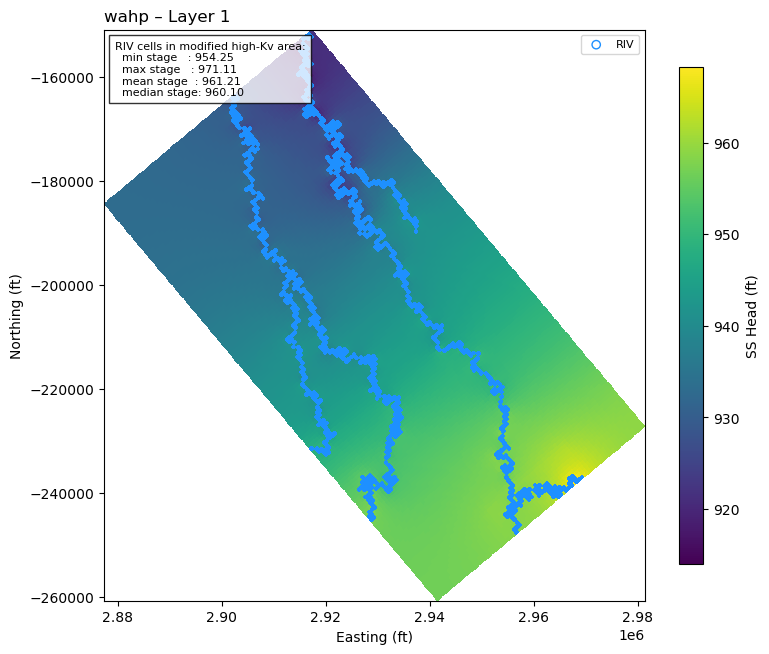

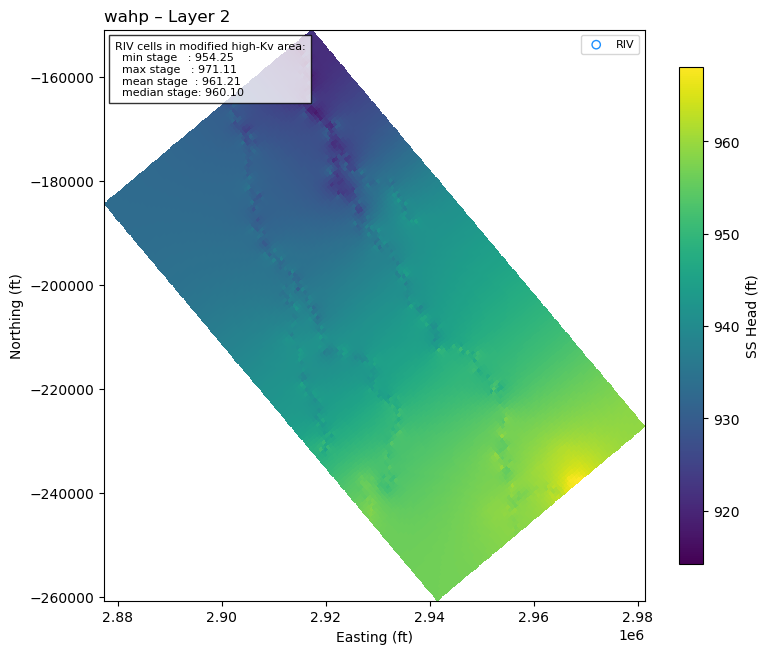

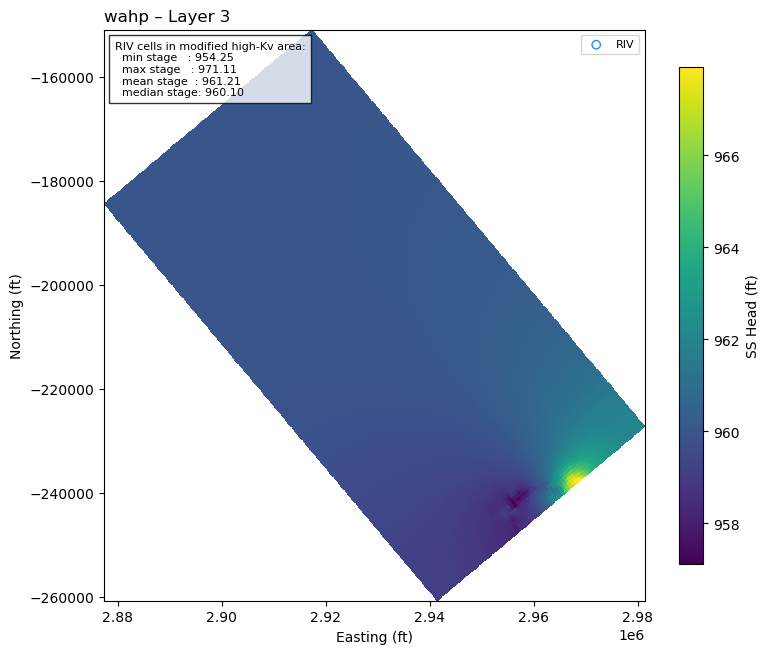

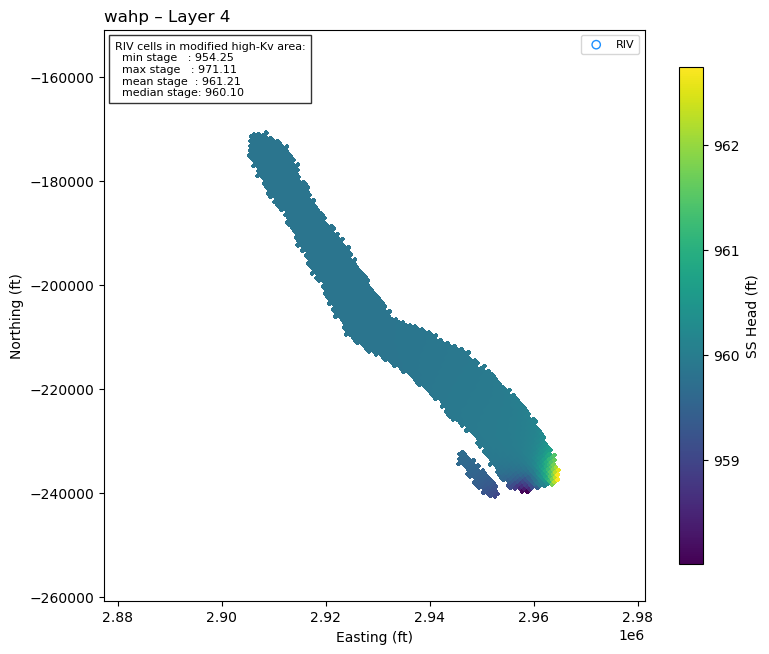

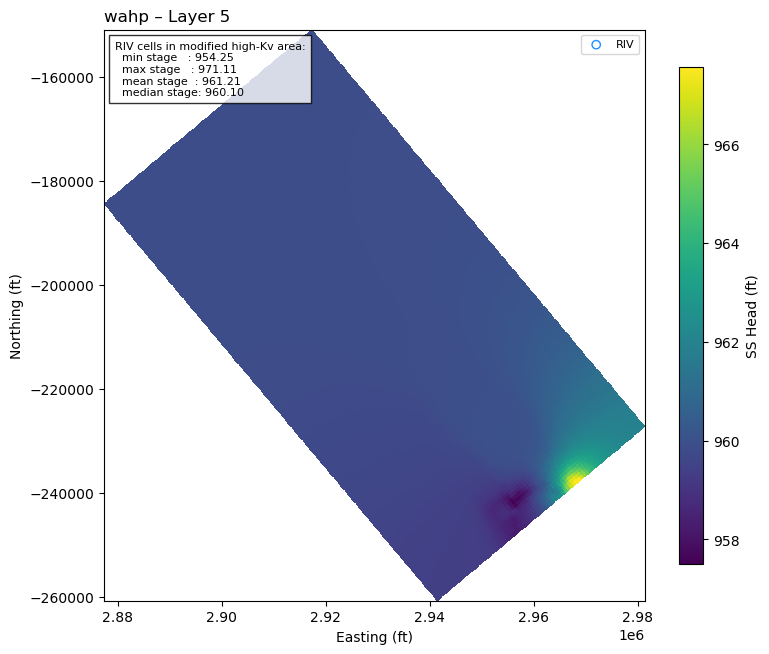

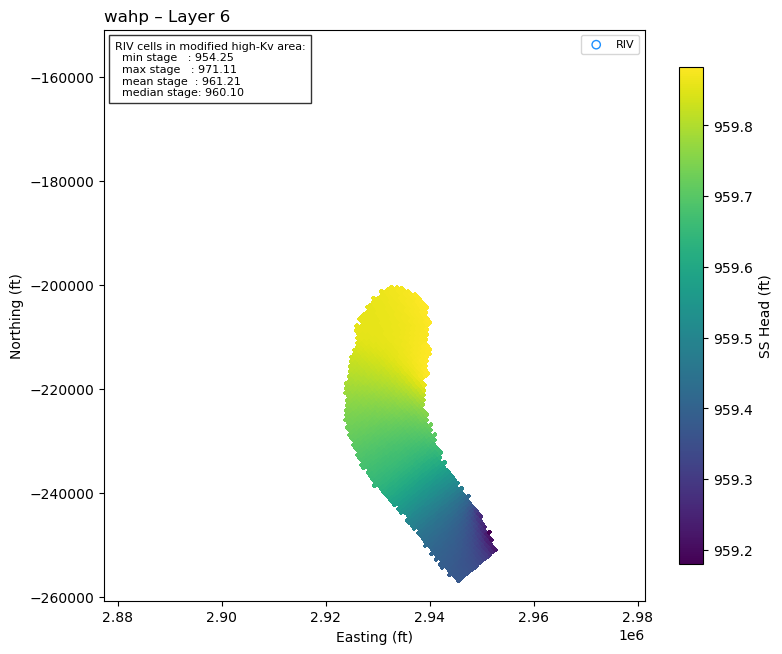

In [23]:
plot_hds(w_d)

In [51]:
from typing import Tuple, Dict, Optional
from flopy.utils import CellBudgetFile, postprocessing as pp


def plot_cross_section(
    model_ws: str,
    sim_name: str = "wahp",
    kstpkper: Tuple[int, int] = (0, 0),
    column: int = 44,                # 1-based model column for the section
    arrow_kw: Optional[Dict] = None,
):
    """
    Column cross-section with layer-4 shading, red specific-discharge
    arrows, and a blue head line through layer 4.

    Parameters
    ----------
    model_ws : str
        MF6 simulation workspace.
    sim_name : str
        GWF model name (.nam prefix).
    kstpkper : (int, int)
        (kstp, kper) tuple for the CBB / head file.
    column : int
        1-based model column number for the cross-section.
    arrow_kw : dict, optional
        Extra kwargs forwarded to PlotCrossSection.plot_vector.
    """
    # ── load simulation (only packages we need) ─────────────────────
    sim = flopy.mf6.MFSimulation.load(
        sim_ws=model_ws, exe_name="mf6", load_only=["dis", "oc", "riv"]
    )
    gwf  = sim.get_model(sim_name)
    grid = gwf.modelgrid

    # ── specific discharge ─────────────────────────────────────────
    oc_file = gwf.oc.budget_filerecord.array[0][0]
    cbc     = CellBudgetFile(os.path.join(model_ws, oc_file), precision="double")
    spdis   = cbc.get_data(text="SPDIS", kstpkper=kstpkper)[0]
    qx, qy, qz = pp.get_specific_discharge(spdis, gwf)

    # ── heads for layer-4 line ─────────────────────────────────────
    heads = flopy.utils.HeadFile(
        os.path.join(model_ws, f"{sim_name}.hds")
    ).get_data(kstpkper=kstpkper)

    # ── set up figure & cross-section object ───────────────────────
    fig, ax = plt.subplots(figsize=(15, 8), dpi=500)
    xs = flopy.plot.PlotCrossSection(
        model=gwf,
        line={"column": column - 1},        # zero-based index
        geographic_coords=True,
        ax=ax,
    )

    xs.plot_grid(ax=ax, linewidth=0.2)
    xs.plot_inactive(color_noflow="grey")

    # shade layer-4 cells (index 3) in light gray
    layer_mask = np.full_like(grid.idomain, np.nan, dtype=float)
    layer_mask[3, :, :] = 0.5
    xs.plot_array(layer_mask, cmap="Greys", alpha=0.35, vmin=0, vmax=1)

    # river boundary
    xs.plot_bc(name="riv", color="cyan")

    # head line in layer 4 (blue)
    xs.plot_surface(
        heads[3],                     # layer 4
        color="blue",
        linewidth=1.2,
        linestyle="-",
    )

    # red flow arrows
    vkw = {"kstep": 2, "hstep": 2}
    if arrow_kw:
        vkw.update(arrow_kw)
    xs.plot_vector(
        qx, qy, qz, ax=ax,
        scale=2, color="red", width=0.002, **vkw
    )

    # ── cosmetics ──────────────────────────────────────────────────
    ax.set_title(f"Cross-section along Column {column}", loc="left")
    ax.set_xlabel("Horizontal coordinate (ft)")
    ax.set_ylabel("Elevation (ft)")
    plt.tight_layout()
    plt.show()

def plot_plan_column(
    model_ws: str,
    sim_name: str = "wahp",
    column: int = 44,                 # 1-based model column to highlight
):
    """
    Plan-view map showing

      • gray mask (rows 141-151, cols 29-58),
      • highlighted column in yellow,
      • river boundary cells (blue),
      • Wahp outline (red).

    Parameters
    ----------
    model_ws : str
        MF6 workspace (e.g. "model_ws/wahp_clean").
    sim_name : str
        GWF model name (.nam prefix).
    column : int
        1-based model column number to highlight.
    """
    # ── load model ─────────────────────────────────────────────────
    sim = flopy.mf6.MFSimulation.load(
        sim_ws=model_ws, exe_name="mf6", load_only=["dis", "riv"]
    )
    gwf   = sim.get_model(sim_name)
    grid  = gwf.modelgrid
    nrows, ncols = grid.nrow, grid.ncol

    # ── build mask exactly as before ──────────────────────────────
    rows = np.arange(141, 152)
    cols = np.arange(29, 59)
    mask = np.zeros((nrows, ncols), dtype=int)
    mask[np.ix_(rows - 1, cols - 1)] = 1          # 0-based index

    # ── highlight the chosen column (yellow) ─────────────────────
    col_high = np.full_like(mask, np.nan, dtype=float)
    col_high[:, column - 1] = 1.0                 # NaN elsewhere, 1 in column

    # ── outline shapefile ─────────────────────────────────────────
    outline_fp = os.path.join(
        "..", "..", "..", "gis", "input_shps", "wahp", "wahp_outline_full.shp"
    )
    outline = gpd.read_file(outline_fp)


    # ── map view ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 7))
    mv = flopy.plot.PlotMapView(model=gwf, ax=ax)

    mv.plot_array(mask, cmap="gray", alpha=0.7, vmin=0, vmax=1)

    mv.plot_array(
        col_high,
        cmap="autumn",                     # oranges/yellows
        alpha=0.8,
        vmin=0,
        vmax=1
    )

    mv.plot_bc(package=gwf.riv, color="blue", lw=0.8, label="River package")

    outline.boundary.plot(ax=ax, color="red", linewidth=1.2, label="Wahp outline")

    ax.set_title(f"Plan view – highlighted Column {column}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    loading package oc...
    skipping package obs...
    skipping package ims6...


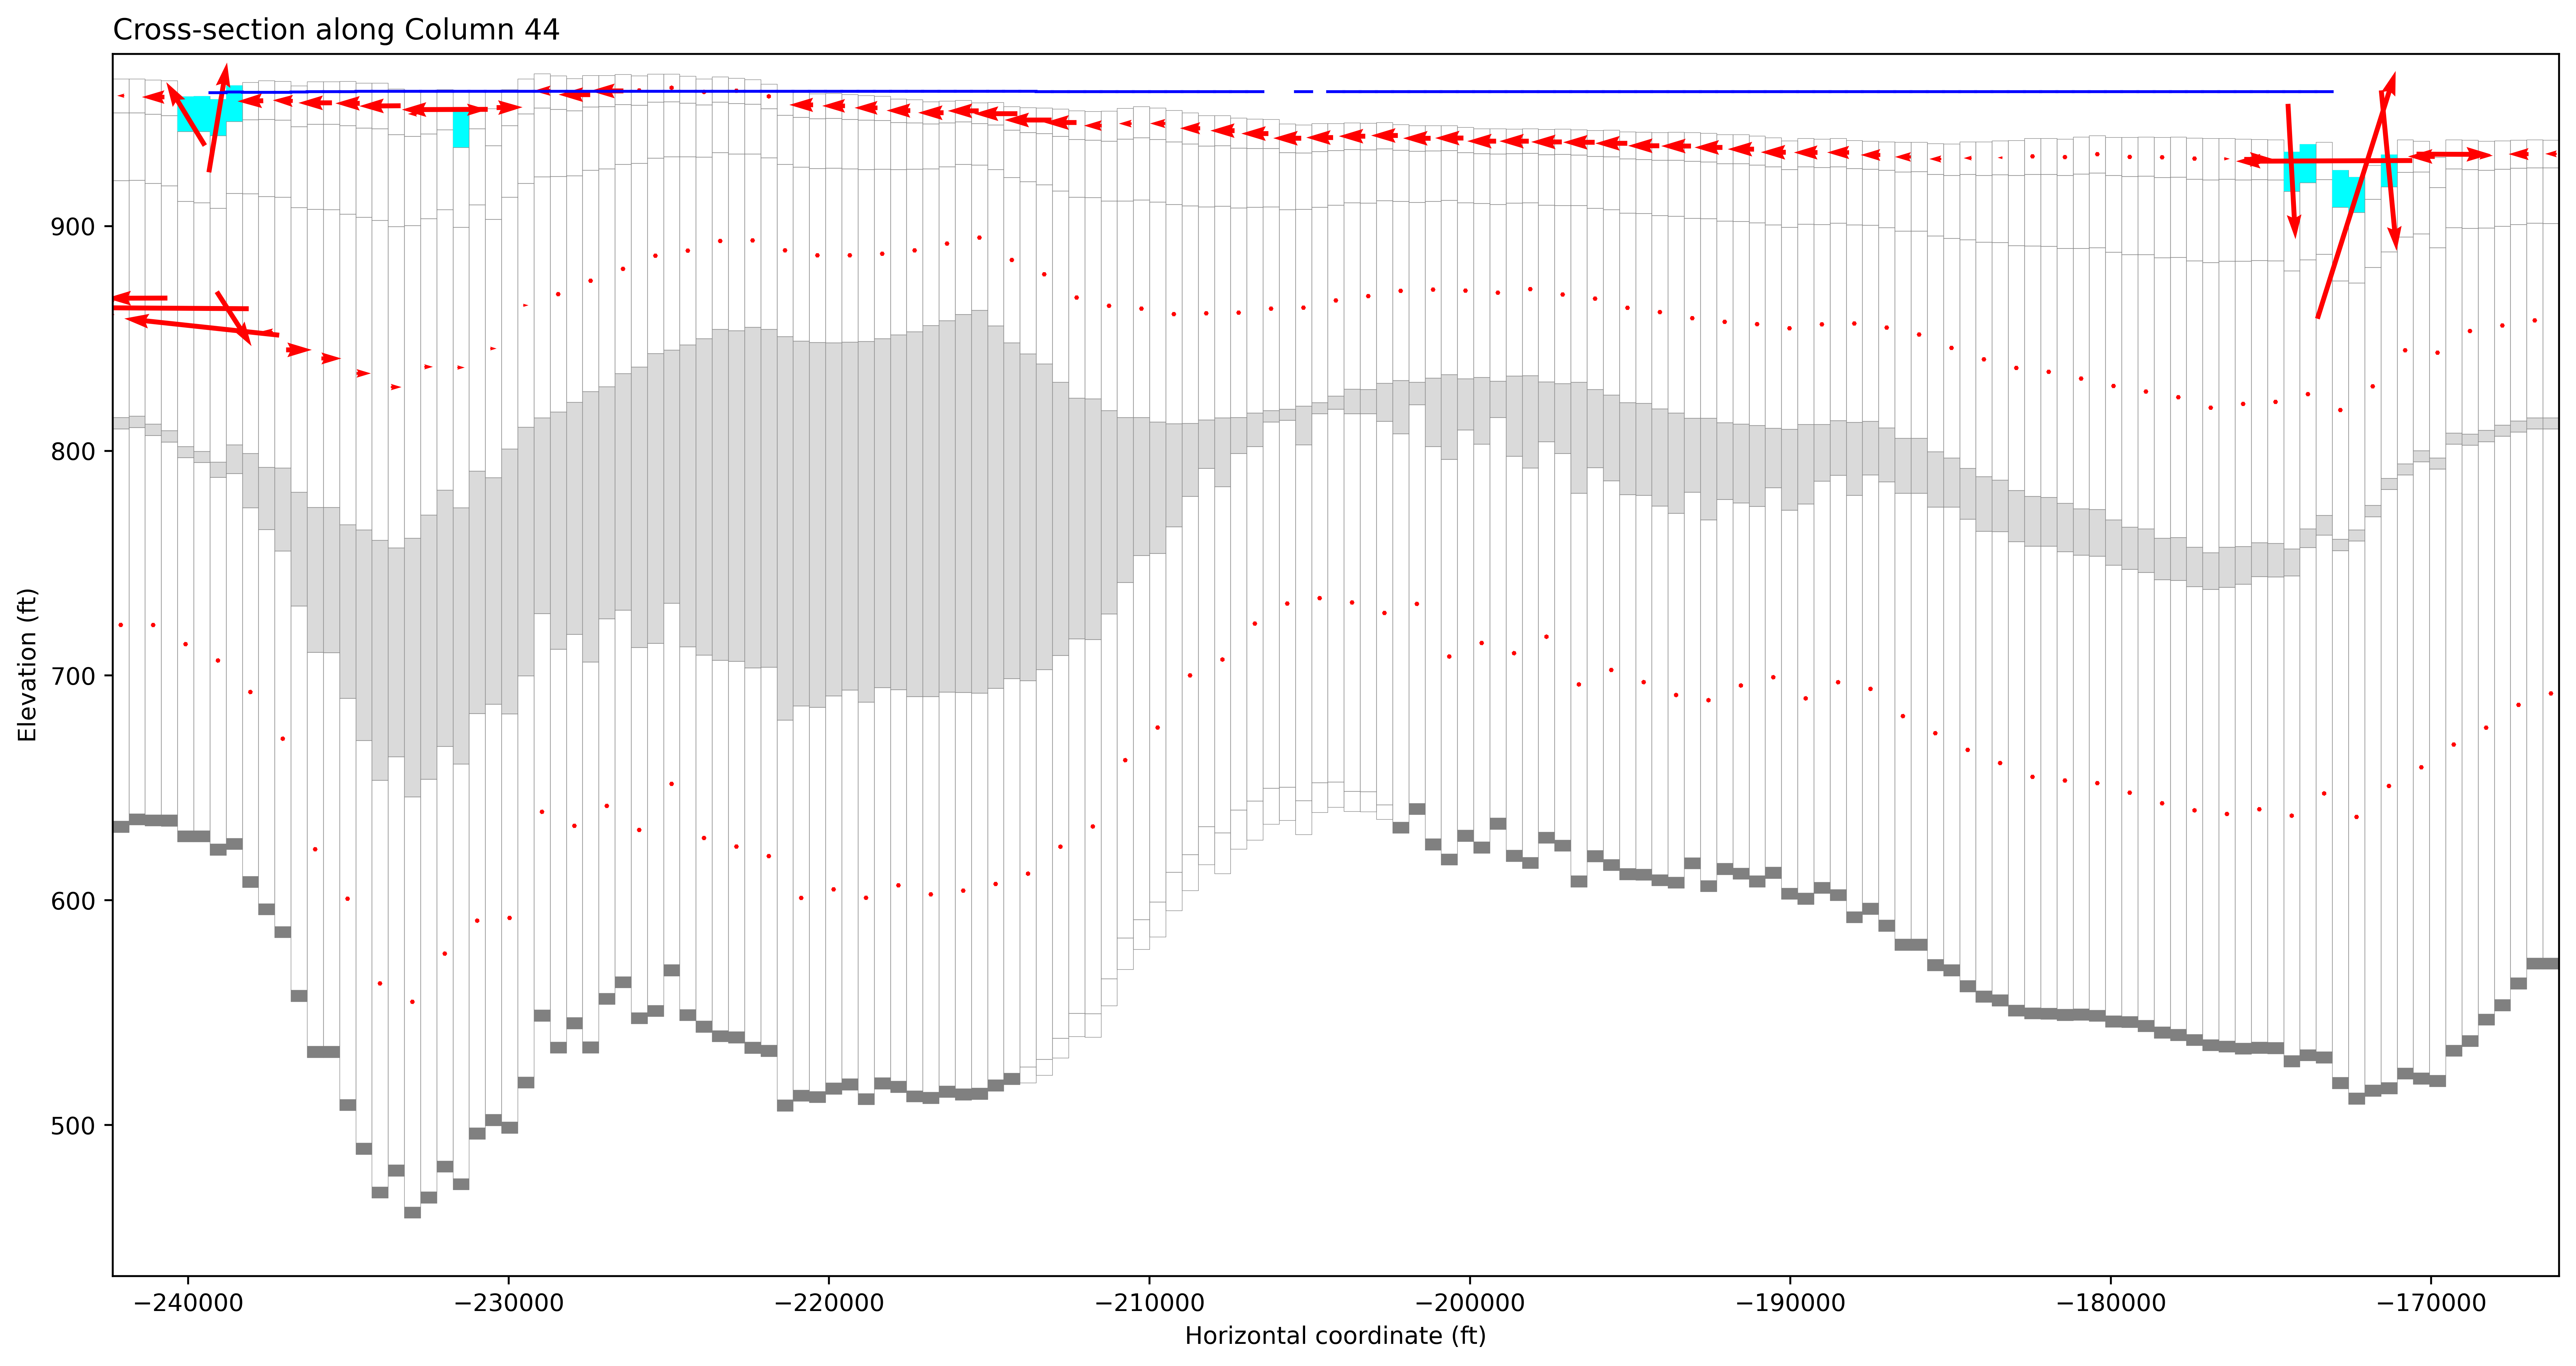

In [45]:
plot_cross_section(model_ws=os.path.join(w_d))

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    skipping package oc...
    skipping package obs...
    skipping package ims6...


C:\Users\mbeck\AppData\Local\Temp\ipykernel_48048\2709120558.py:157: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


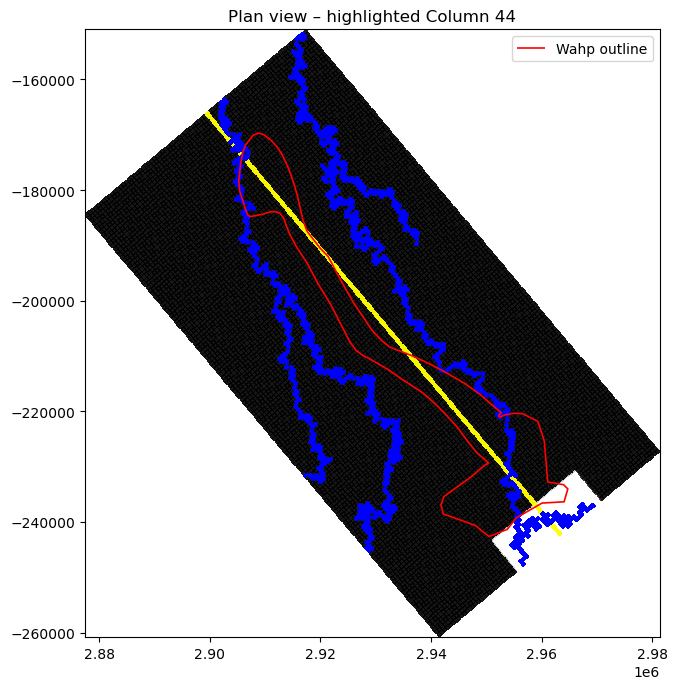

In [52]:
plot_plan_column(w_d, column=44)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    skipping package riv...
    skipping package oc...
    skipping package obs...
    skipping package ims6...
→ running mf6 for Kv = 1e-10
→ running mf6 for Kv = 1e-05
→ running mf6 for Kv = 1e-04
→ running mf6 for Kv = 1e-03
→ running mf6 for Kv = 1e-02
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    loading package oc...
    skipping package obs...
    skipping package ims6...


AttributeError: 'PlotCrossSection' object has no attribute 'xsection'

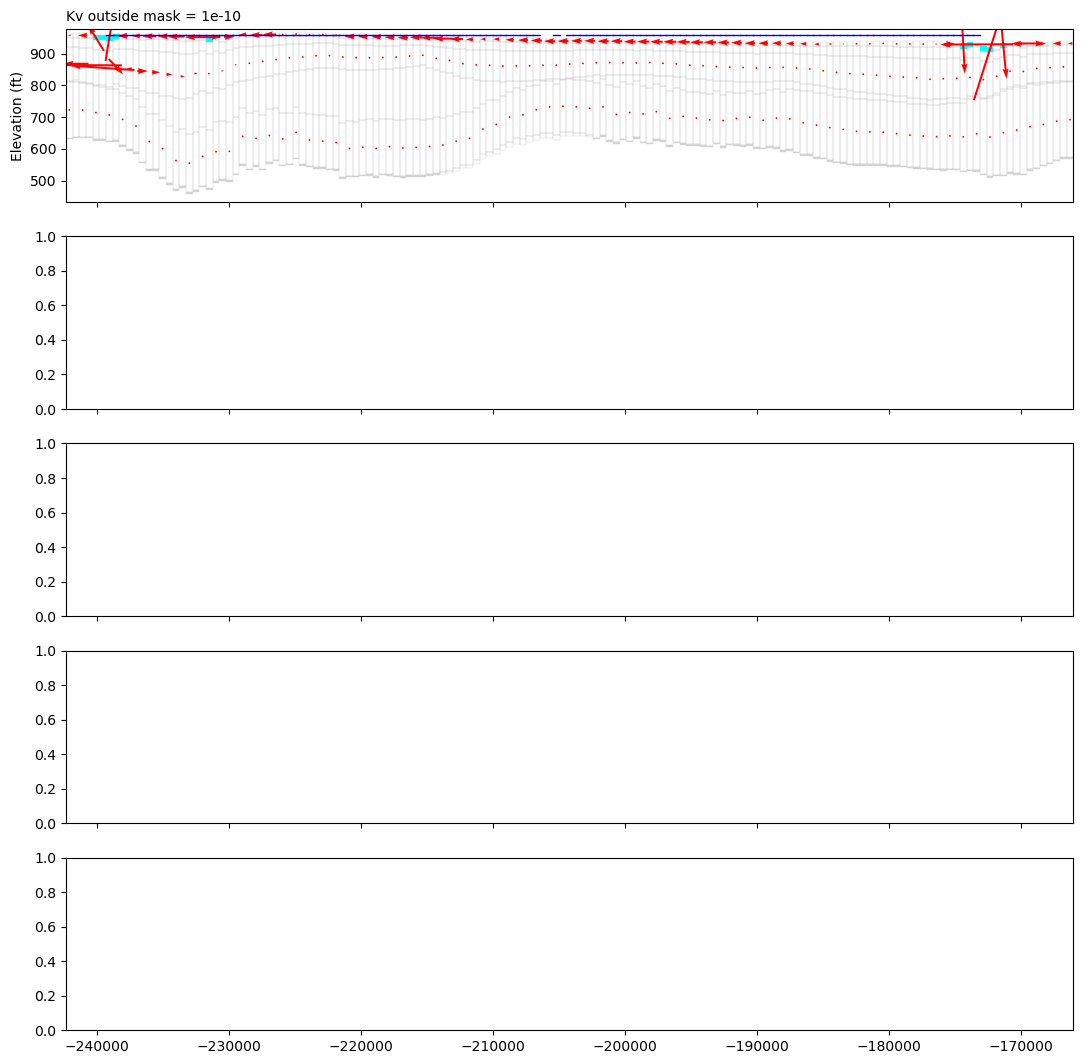

In [54]:
base_ws   = w_d                         # your original workspace, e.g. "model_ws/wahp_clean"
kv_vals   = [1e-10, 1e-5, 1e-4, 1e-3, 1e-2]
xsec_col  = 44                          # 1-based column for the cross-section
nstress   = (0, 0)                      # kstpkper to plot

# ----------------------------------------------------------------------------------
import os, shutil, subprocess, sys, glob
from flopy.utils import CellBudgetFile, postprocessing as pp

sim0  = flopy.mf6.MFSimulation.load(sim_ws=base_ws, exe_name="mf6", load_only=["dis"])
grid  = sim0.get_model().modelgrid
nrows, ncols = grid.nrow, grid.ncol

rows = np.arange(141, 152)
cols = np.arange(29, 59)
mask = np.zeros((nrows, ncols), dtype=bool)
mask[np.ix_(rows - 1, cols - 1)] = True          # True where high-Kv zone is

# ----------------------------------------------------------------------------------
def make_variant_ws(src_ws: str, kv_val: float) -> str:
    """Copy workspace → set layer-3 K33 outside mask to kv_val (no renaming)."""
    tag = f"kv_{kv_val:.0e}"
    dst = f"{src_ws}_{tag}"
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src_ws, dst)

    # edit layer-3 K33 array
    l3_file = glob.glob(os.path.join(dst, "npf_k33_layer3*.txt"))[0]
    arr     = np.loadtxt(l3_file)
    arr[~mask] = kv_val
    np.savetxt(l3_file, arr, fmt="%.12e")

    # return workspace and the unchanged model name (wahp)
    mname = "wahp"
    return dst, mname


def run_mf6(ws: str):
    """run mf6 in workspace; print stderr on error"""
    res = subprocess.run(["mf6"], cwd=ws, capture_output=True, text=True)
    if res.returncode != 0:
        print("---------- mf6 stderr ----------")
        print(res.stderr)
        print("--------------------------------")
        res.check_returncode()


# ----------------------------------------------------------------------------------
# create & run all variants
variant_info = []
for kv in kv_vals:
    ws, mname = make_variant_ws(base_ws, kv)
    print(f"→ running mf6 for Kv = {kv:.0e}")
    run_mf6(ws)
    variant_info.append((ws, mname, kv))


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    skipping package oc...
    skipping package obs...
    skipping package ims6...
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    loading package oc...
    skipping package obs...
    skipping package ims6...
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    skipping package oc...
    skipping package obs...
    skipping package ims6...
loading simulation..

C:\Users\mbeck\AppData\Local\Temp\ipykernel_48048\2356008074.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


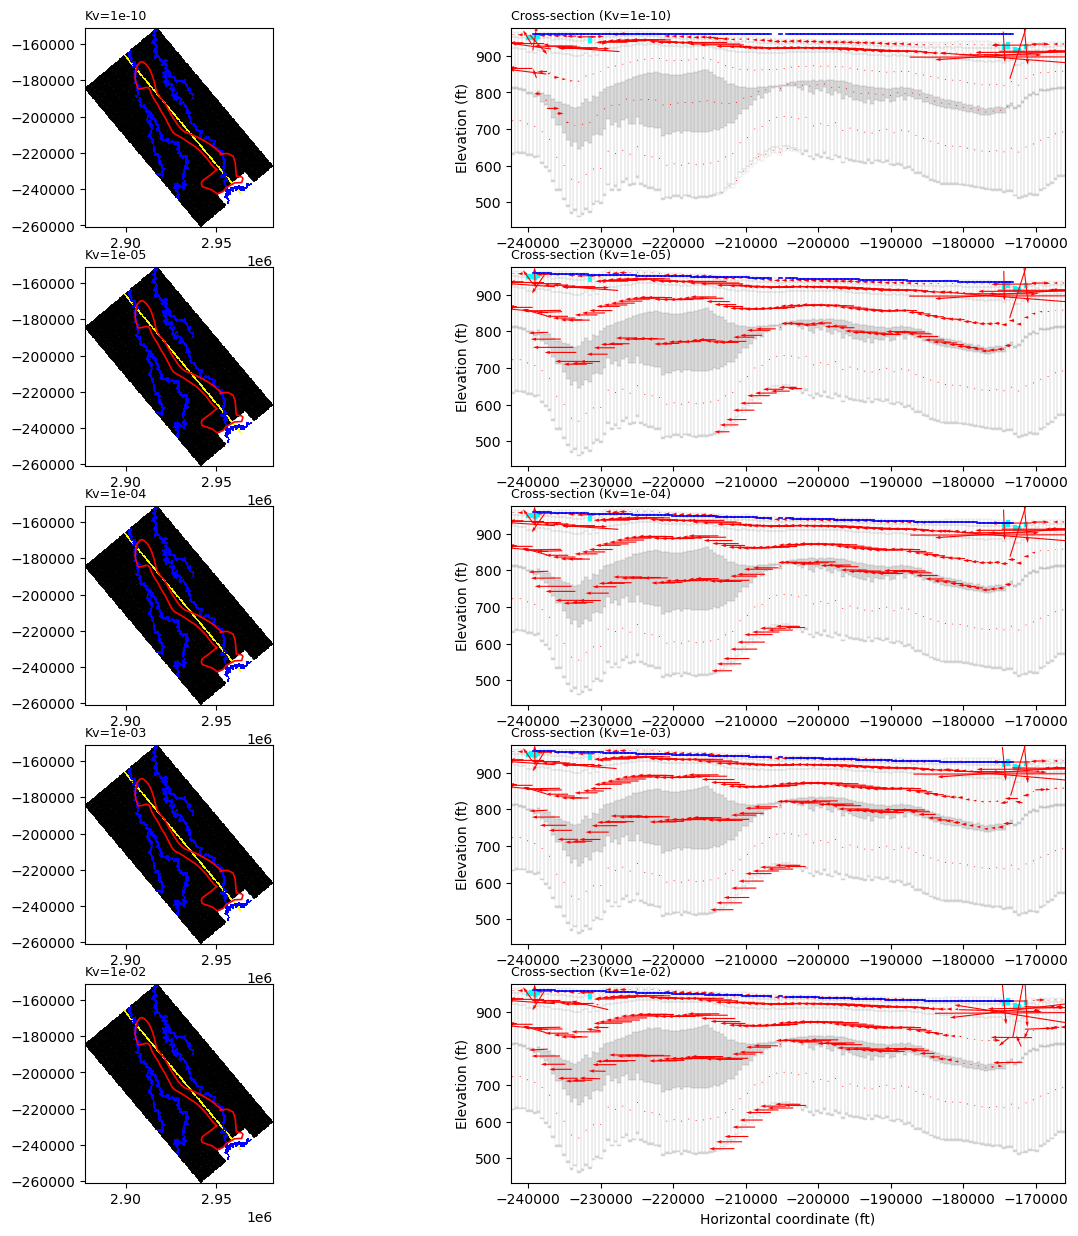

In [65]:
# ----------------------------------------------------------------------------------
#  STACKED PLAN + CROSS-SECTION FIGURE FOR ALL Kv VARIANTS
# ----------------------------------------------------------------------------------
from flopy.utils import CellBudgetFile, postprocessing as pp
import re

# base workspace that you cloned
base_ws = w_d                                 # e.g. "model_ws/wahp_clean"

# discover variant directories and sort by numeric Kv
variant_dirs = sorted(
    glob.glob(f"{base_ws}_kv_*"),
    key=lambda p: float(re.search(r"kv_([0-9eE\-\+]+)", p).group(1))
)

kv_labels = [re.search(r"kv_([0-9eE\-\+]+)", p).group(1) for p in variant_dirs]

# -------------------------------------------------------------------
# helper that plots onto a passed-in axis (no new figure)
# -------------------------------------------------------------------
def cross_section_on_ax(model_ws, ax, column=44, kstpkper=(0, 0)):
    sim = flopy.mf6.MFSimulation.load(
        sim_ws=model_ws, exe_name="mf6", load_only=["dis", "oc", "riv"]
    )
    gwf  = sim.get_model("wahp")

    # specific discharge
    oc_file = gwf.oc.budget_filerecord.array[0][0]
    cbc     = CellBudgetFile(os.path.join(model_ws, oc_file), precision="double")
    spdis   = cbc.get_data(text="SPDIS", kstpkper=kstpkper)[0]
    qx, qy, qz = pp.get_specific_discharge(spdis, gwf)

    # heads
    heads = flopy.utils.HeadFile(os.path.join(model_ws, "wahp.hds")).get_data(kstpkper=kstpkper)

    xs = flopy.plot.PlotCrossSection(
        model=gwf, line={"column": column - 1}, geographic_coords=True, ax=ax
    )
    xs.plot_grid(ax=ax, linewidth=0.1)
    xs.plot_inactive(color_noflow="lightgrey")
    layer_mask = np.full_like(gwf.modelgrid.idomain, np.nan, dtype=float)
    layer_mask[3, :, :] = 0.5                       # 0.5 → mid-gray
    xs.plot_array(layer_mask, cmap="Greys",
                  alpha=0.35, vmin=0, vmax=1)
    xs.plot_bc(name="riv", color="cyan")

    # layer-4 head line
    xs.plot_surface(heads[3], color="blue", linewidth=1.2)
    xs.plot_vector(qx, qy, qz, ax=ax, color="red", kstep=1, hstep=2, width=0.002, scale=2) 

    ax.set_xlabel("")
    ax.set_ylabel("Elevation (ft)")
    #ax.set_xlim(xs.xsection[0].min(), xs.xsection[0].max())


def plan_on_ax(model_ws, ax, column=44):
    sim = flopy.mf6.MFSimulation.load(
        sim_ws=model_ws, exe_name="mf6", load_only=["dis", "riv"]
    )
    gwf   = sim.get_model("wahp")
    grid  = gwf.modelgrid
    nrows, ncols = grid.nrow, grid.ncol

    rows = np.arange(141, 152)
    cols = np.arange(29, 59)
    mask = np.zeros((nrows, ncols), dtype=int)
    mask[np.ix_(rows - 1, cols - 1)] = 1

    col_high = np.full_like(mask, np.nan, dtype=float)
    col_high[:, column - 1] = 1.0

    mv = flopy.plot.PlotMapView(model=gwf, ax=ax)
    mv.plot_array(mask, cmap="gray", alpha=0.7, vmin=0, vmax=1)
    mv.plot_array(col_high, cmap="autumn", alpha=0.8, vmin=0, vmax=1)
    mv.plot_bc(package=gwf.riv, color="blue", lw=0.8)

    outline_fp = os.path.join(
        "..", "..", "..", "gis", "input_shps", "wahp", "wahp_outline_full.shp"
    )
    outline = gpd.read_file(outline_fp)
    outline.boundary.plot(ax=ax, color="red", linewidth=1.2)

    ax.set_xlabel("")
    ax.set_ylabel("")

# -------------------------------------------------------------------
#  build the stacked figure
# -------------------------------------------------------------------
n = len(variant_dirs)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(15, 3*n), gridspec_kw={"wspace":0.1})

for idx, (ws, kv) in enumerate(zip(variant_dirs, kv_labels)):
    # plan view (left)
    plan_on_ax(ws, axes[idx, 0])
    axes[idx, 0].set_title(f"Kv={kv}", loc="left", fontsize=9)

    # cross-section (right)
    cross_section_on_ax(ws, axes[idx, 1])
    axes[idx, 1].set_title(f"Cross-section (Kv={kv})", loc="left", fontsize=9)

axes[-1, 1].set_xlabel("Horizontal coordinate (ft)")
fig.tight_layout()
plt.show()


In [225]:

def plot_params_map_mel(
    model_ws: Union[str, os.PathLike],
    partype: str,
    sim_name: str = "wahp",
    layers: Union[str, Sequence[int]] = "all",
    kstpkper: tuple[int, int] = (0, 0),          # for recharge only
    logscale_hk: bool = True,
    cmap_overrides: dict[str, str] | None = None,
    out_dir: str = "fig_params",
    dpi: int = 300,
):
    """
    Colour-flood maps of HK, VK, SS, SY or RECH ― one PNG per layer ― with the
    Wahpeton project outline shown as a grey basemap.
    """

    # ── helper to unwrap LayeredArray/Util3D → ndarray
    def _to_array(obj):
        return obj.array if hasattr(obj, "array") else obj

    # ── colour maps
    cmaps = dict(hk="plasma", vk="plasma", ss="viridis",
                 sy="YlGn", rech="Blues")
    if cmap_overrides:
        cmaps.update({k.lower(): v for k, v in cmap_overrides.items()})

    partype = partype.lower()
    if partype not in {"hk", "vk", "ss", "sy", "rech"}:
        raise ValueError("partype must be hk, vk, ss, sy or rech")

    # ── load simulation & model
    model_ws = os.fspath(model_ws)
    sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws, exe_name="mf6")
    gwf = sim.get_model(sim_name)
    grid = gwf.modelgrid
    idomain = grid.idomain

    nlay = gwf.dis.nlay.data
    if layers == "all":
        layers = range(nlay)

    # ── read outline shapefile once and match CRS
    gis_dir = os.path.join("..","..", "..", "gis")
    outline_fp = os.path.join(gis_dir, "input_shps",
                              "wahp", "wahp_outline_full.shp")
    outline = gpd.read_file(outline_fp)


    # ── fetch requested parameter array
    if partype == "hk":
        arr3d = _to_array(gwf.npf.k)

    elif partype == "vk":
        raw = getattr(gwf.npf, "k33", None) or getattr(gwf.npf, "vk", None)
        if raw is None:
            raise ValueError("Model has neither K33 nor VK defined.")
        arr3d = _to_array(raw)

    elif partype == "ss":
        arr3d = _to_array(gwf.sto.ss)

    elif partype == "sy":
        arr3d = _to_array(gwf.sto.sy)

    elif partype == "rech":
        if not hasattr(gwf, "rch"):
            raise ValueError("Model has no RCH package.")

        full = _to_array(gwf.rch.recharge)          # 2-, 3- or 4-D
        if full.ndim == 4:                          # (nper, nlay, nrow, ncol)
            arr2d = full[kstpkper[1], 0, :, :]
        elif full.ndim == 3:                        # (nper, nrow, ncol)
            arr2d = full[kstpkper[1]]
        else:                                       # steady 2-D
            arr2d = full

        arr3d = arr2d[np.newaxis, ...]              # fake 3-D for loop
        layers = [0]

    # ── output folder
    figdir = os.path.join(model_ws, out_dir)
    os.makedirs(figdir, exist_ok=True)
    cmap = mpl.colormaps.get_cmap(cmaps[partype])

    # ── loop over layers
    for k in layers:
        data = arr3d[k]
        active = idomain[min(k, idomain.shape[0]-1)] > 0
        data_m = np.ma.masked_where(~active |
                                    (data <= -1e30) | (data >= 1e30), data)

        # colour norm
        if partype in {"hk", "vk"} and logscale_hk:
            data_m = np.ma.masked_where(data_m <= 0, data_m)
            norm = mpl.colors.LogNorm(vmin=data_m.min(), vmax=data_m.max())
        else:
            norm = mpl.colors.Normalize(vmin=data_m.min(), vmax=data_m.max())

        # ── plotting
        fig, ax = plt.subplots(figsize=(8, 7))

        # 2) parameter colour-flood
        mview = flopy.plot.PlotMapView(model=gwf, layer=k, ax=ax)
        mview.plot_array(data_m, cmap=cmap, norm=norm)
                # 1) grey outline basemap
        outline.plot(ax=ax, facecolor="none", edgecolor="0.4", linewidth=1.0)
        plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                     ax=ax, shrink=0.8,
                     label=("Recharge (ft/d)" if partype == "rech"
                            else partype.upper()))

        title = (f"{sim_name} – RECH (kstpkper {kstpkper})"
                 if partype == "rech"
                 else f"{sim_name} – {partype.upper()} layer {k + 1}")
        ax.set_title(title, loc="left")
        ax.set_aspect("equal")
        ax.set_xlabel("Easting (ft)")
        ax.set_ylabel("Northing (ft)")
        fig.tight_layout()

        fname = (f"rech_kstpkper_{kstpkper[0]}_{kstpkper[1]}.png"
                 if partype == "rech"
                 else f"{partype}_layer_{k + 1:02d}.png")
        png = os.path.join(figdir, fname)
        fig.savefig(png, dpi=dpi)
        #plt.close(fig)
        print("saved →", png)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package drn...
    loading package oc...
    loading package obs...
  loading solution package wahp...
saved → test_case_03\fig_params\vk_layer_01.png
saved → test_case_03\fig_params\vk_layer_02.png
saved → test_case_03\fig_params\vk_layer_03.png
saved → test_case_03\fig_params\vk_layer_04.png
saved → test_case_03\fig_params\vk_layer_05.png
saved → test_case_03\fig_params\vk_layer_06.png


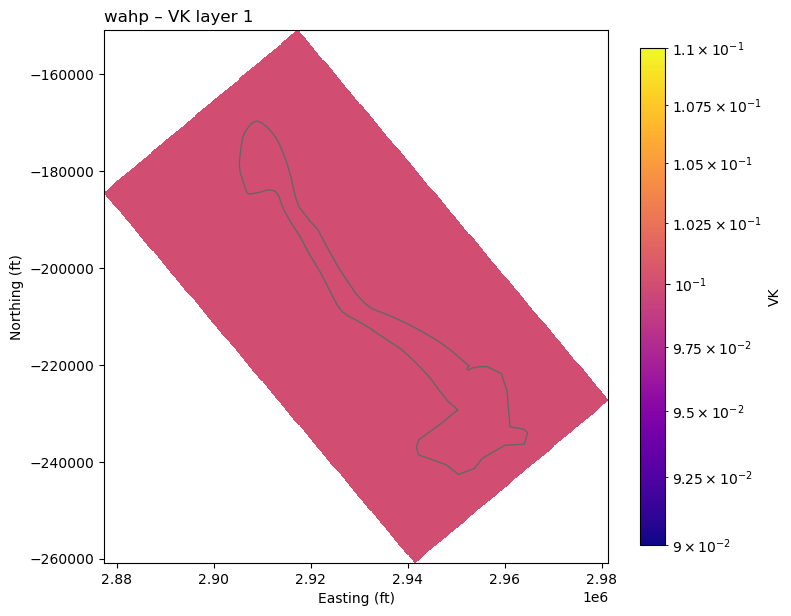

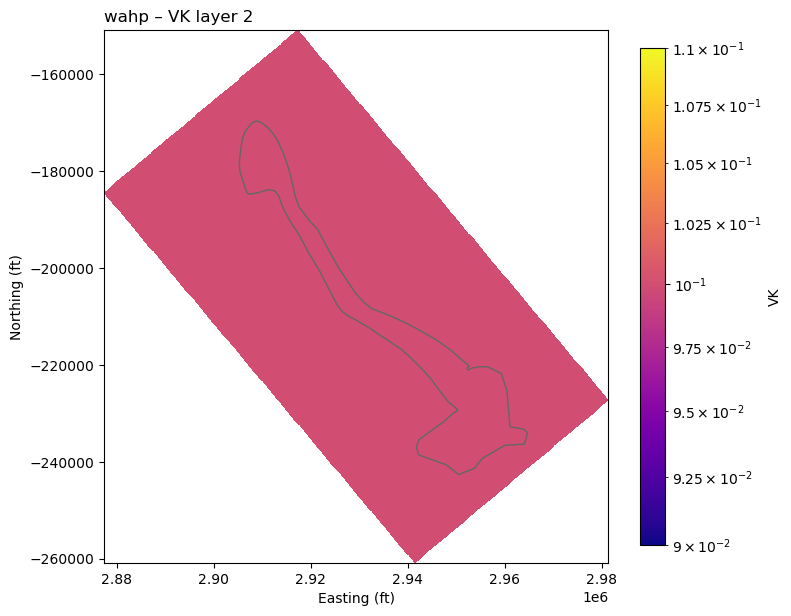

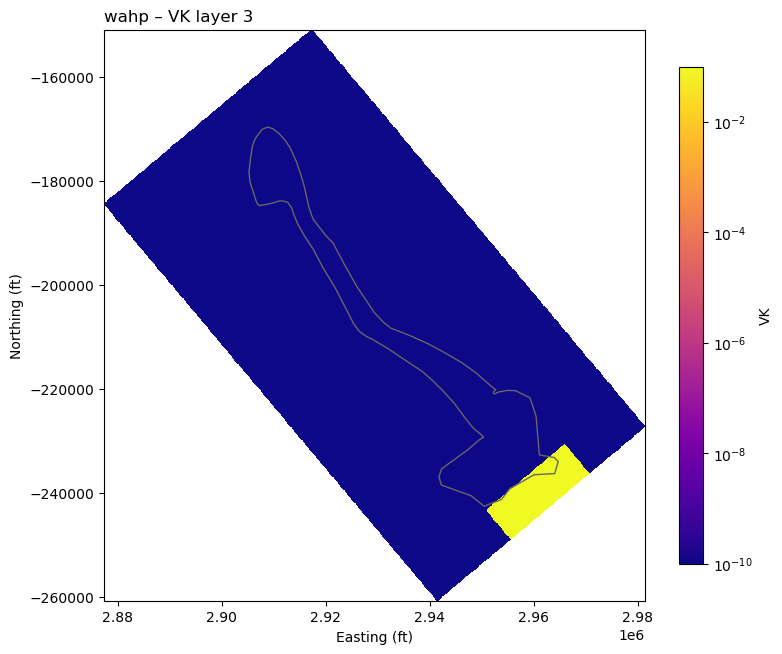

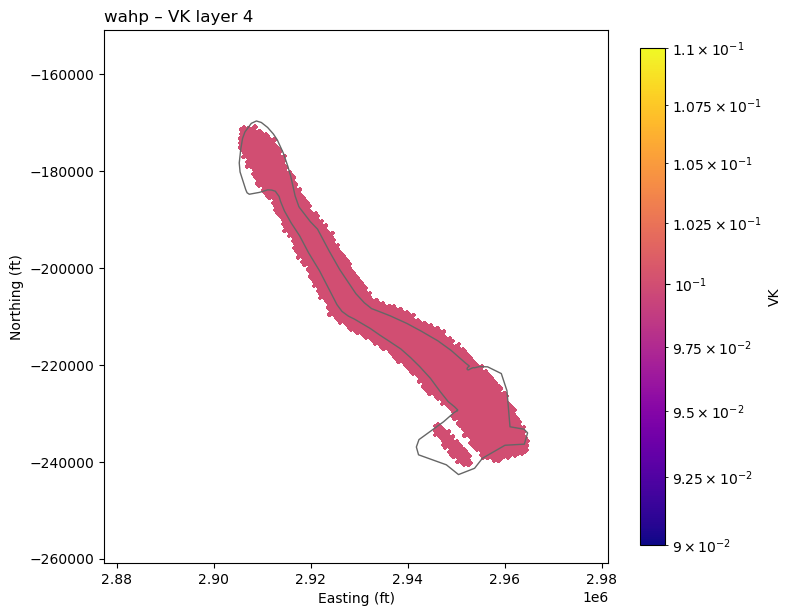

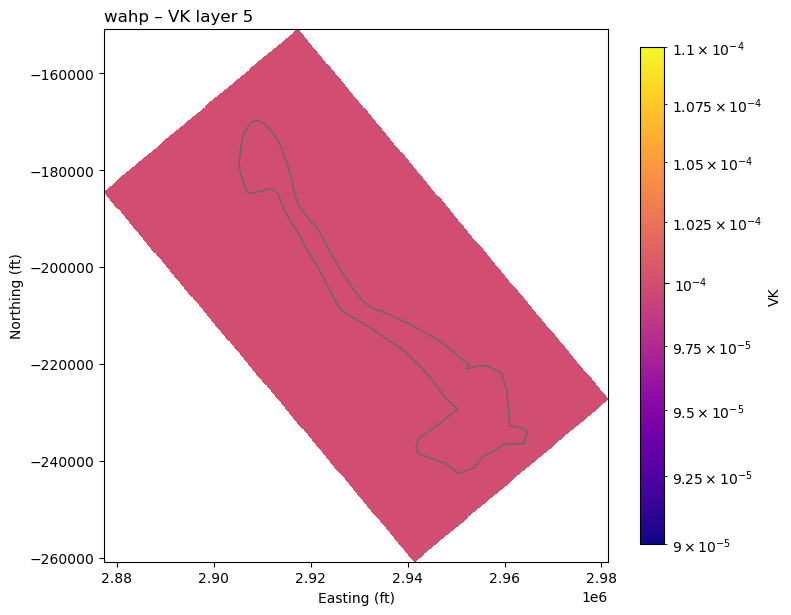

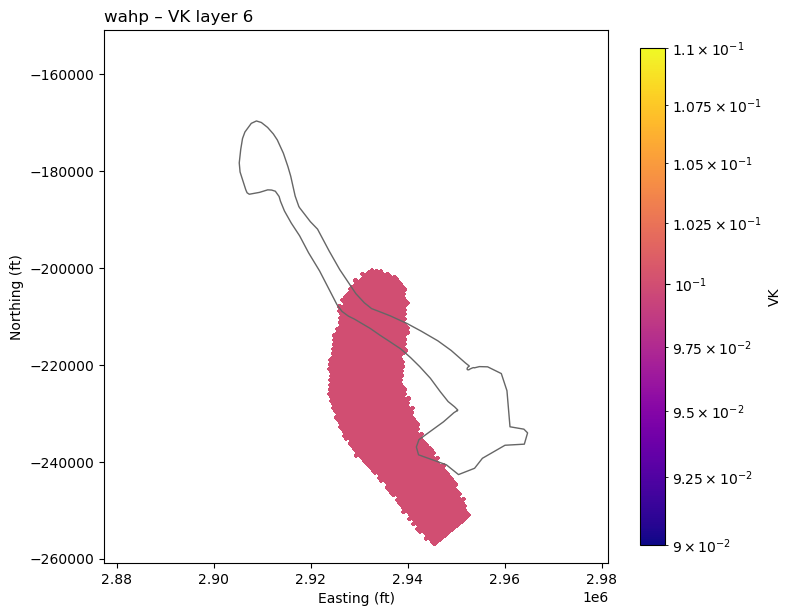

In [226]:
plot_params_map_mel(w_d,partype="vk", logscale_hk = True)

In [227]:
def plot_flow_xsec(workspace,row=140):
    from flopy.utils import CellBudgetFile, postprocessing as pp
    sim = flopy.mf6.MFSimulation.load(sim_ws=workspace,load_only=["dis","oc","riv","rch"])
    model = sim.get_model()
    
    cbc = CellBudgetFile(os.path.join(workspace,model.oc.budget_filerecord.array[0][0]), precision="double")
    kstpkper = np.array(cbc.get_kstpkper())
    spdis = cbc.get_data(text="SPDIS", kstpkper=(0, 0))[0]
    qx, qy, qz = pp.get_specific_discharge(spdis, model)
    xcent, ycent, zcent = model.modelgrid.xyzcellcenters
    arrow_kw = {}
    fig, ax = plt.subplots(figsize=(15,8), dpi=500)
    xs = flopy.plot.PlotCrossSection(model=model, line={"row": row-1},
                                geographic_coords=True, ax=ax)  
    
    xs.plot_bc(name="riv",color="cyan")
    vkw = {"kstep": 1, "hstep": 1}
    vkw.update(arrow_kw or {})
    arrow_plt=xs.plot_vector(qx, qy, qz, ax=ax,**vkw,scale=2,color="b",width=0.002)
    xs.plot_grid(ax=ax, linewidth=0.1)
    xs.plot_inactive(color_noflow='grey')
    
    ax.set_title(f"Xsec: Row {row}, high Kv+low RCH", size=12)
    ax.set_xlabel("Lateral Coordinate (ft)")
    ax.set_ylabel("Elevation (ft)")
    plt.tight_layout()


    #checking for face flux
    # flow_riv=cbc.get_data(full3D=True,kstpkper=(0, 0),text='RIV')
    # flow_riv[0][0][flow_riv[0][0]==0]=np.nan
    # plt.imshow(flow_riv[0][0],vmin=-30000,vmax=30000,cmap="seismic"); plt.colorbar(); plt.show()
    
    # flowja = cbc.get_data(idx=2,full3D=True,kstpkper=(0, 0))[0]
    # MF6_face_flows=flopy.mf6.utils.get_structured_faceflows(flowja, grb_file=os.path.join(workspace,"wahp.dis.grb"))
    # mf6_vflow_array=MF6_face_flows[2]
    # mf6_vflow_array[mf6_vflow_array==0]=np.nan
    

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    skipping package drn...
    loading package oc...
    skipping package obs...
    skipping package ims6...


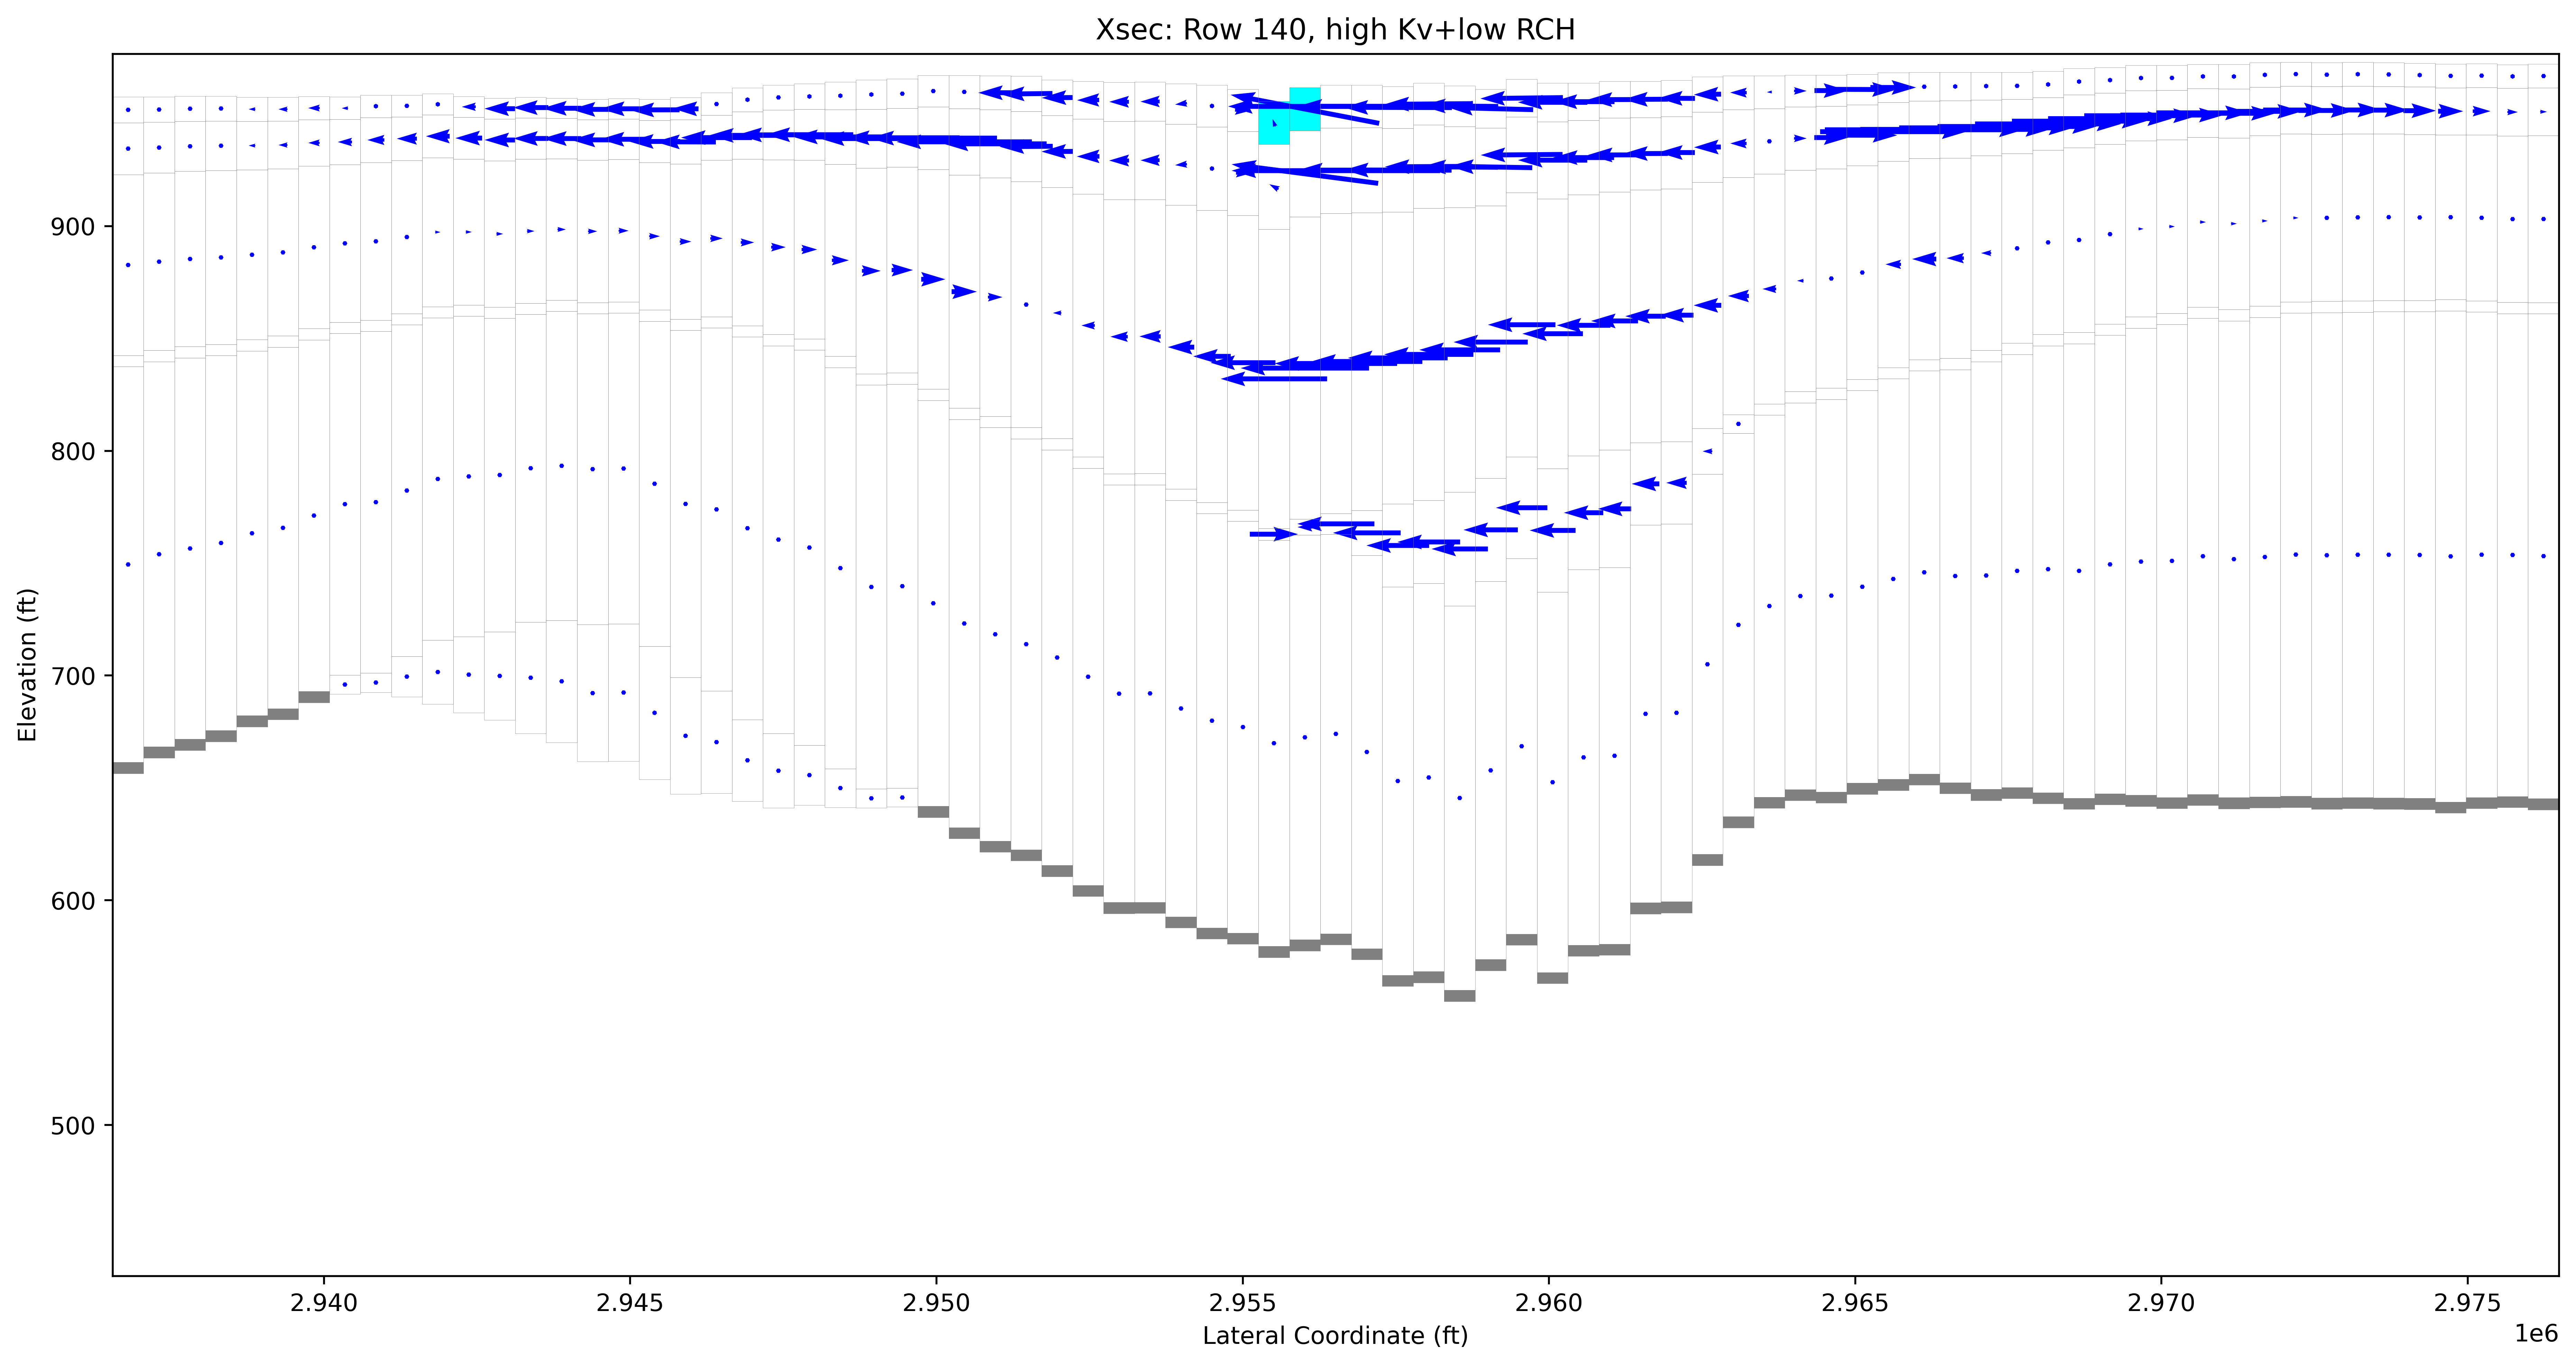

In [228]:
plot_flow_xsec(w_d,row=140)